<a href="https://colab.research.google.com/github/lkeeeeeee/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_4%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 오픈소스 기반 데이터 분석 4강 - 데이터 수집


## 4-1 CSV 파일 읽기

In [ ]:
import pandas as pd

## data.csv 파일 읽기
df = pd.read_csv('data.csv', encoding = 'utf-8', sep = ',', header=0,
                    index_col = None, skiprows = None, nrows= None)
print(df)

           날짜    체중  골격근량  체지방량
0  2025.02.06  64.7  30.0  11.1
1  2025.02.04  64.0  29.3  11.6


## 4-2 JSON 파일 읽기



In [ ]:
import json
import pandas as pd

## data.json 파일 출력
with open('data.json', mode = 'r' , encoding = 'utf-8') as f:
    data = json.load(f)
print(data)
## data.json 파일 DataFrame 읽기
df = pd.read_json('data.json', orient='records', encoding= 'utf-8')
print(df)

{'매출데이터': [{'월': '2025-01', '매출액': 1000000, '비용': 700000, '이익': 300000}, {'월': '2025-02', '매출액': 1200000, '비용': 800000, '이익': 400000}, {'월': '2025-03', '매출액': 1500000, '비용': 900000, '이익': 600000}]}
                                               매출데이터
0  {'월': '2025-01', '매출액': 1000000, '비용': 700000,...
1  {'월': '2025-02', '매출액': 1200000, '비용': 800000,...
2  {'월': '2025-03', '매출액': 1500000, '비용': 900000,...


## 4-3 텍스트 파일 읽기 및 데이터 추출

In [ ]:
import re

## 파일(callcenter20250301.log) 오픈 및 읽기
with open('callcenter20250301.log', 'r', encoding='utf-8') as f:
    content = f.read()
## 주민등록번호 패턴 생성
pattern = re.compile(r'(\d{6})-(\d{7})')
## 주민등록번호 마스킹
masked_content = pattern.sub(r'\1-*******', content)

## 마스킹된 파일(callcenter20250301_masked.log) 오픈 및 쓰기
with open('callcenter20250301.log', 'w') as f:
    f.write(masked_content)

print("주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.")

주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.


## 4-4 Open-Meteo의 무료 날씨 API를 통한 특정 지역 온도 조회

In [ ]:
import requests
import json

url = "https://api.open-meteo.com/v1/forecast?=&=&current=temperature_2m"
params = {
    "latitude": "34.58638333",
    "longitude": "127.0203333",
    "current": "temperature_2m"
}

try:
    ## URL 및 파라미터 전송
    response = requests.get(url, params = params )
    response.raise_for_status()

    ## JSON 데이터 읽기
    data = response.json();
    print("API 응답:", data)
    print("서울시 종로구의 현재 온도는 : {0}{1} 입니다.".format(data['current']['temperature_2m'], data['current_units']['temperature_2m']))

except requests.exceptions.RequestException as e:
    print(f"API 호출 실패: {e}")
except json.JSONDecodeError as e:
    print(f"JSON 파싱 실패: {e}")

API 응답: {'latitude': 34.6, 'longitude': 127.0, 'generationtime_ms': 1.1353492736816406, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 0.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C'}, 'current': {'time': '2026-09-28T15:15', 'interval': 900, 'temperature_2m': 20.2}}
서울시 종로구의 현재 온도는 : 20.2°C 입니다.


## 4-5 Selenium과 lxml을 이용한 웹 스크래핑

In [ ]:
!curl -o google-chrome-stable_current_amd64.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install ./google-chrome-stable_current_amd64.deb -y
!pip install selenium webdriver_manager

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  135M  100  135M    0     0   154M      0 --:--:-- --:--:-- --:--:--  154M
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
The following additional packages will be installed:
  at-spi2-common at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0t64
  libatk1.0-0t64 libatspi2.0-0t64 libxcomposite1 libxtst6 session-migration
The following NEW packages will be installed:
  at-spi2-common at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0t64 libatk1.0-0t64 libatspi2.0-0t64 libxcomposite1
  libxtst6 session-migration
0 upgraded, 10 newly installed, 0 to remove and 0 not upgraded.
Need to get 331 kB/142 MB of archives.
After this operation, 458 MB of addition

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from lxml import html
import time

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')               # 브라우저 창 없이 실행
chrome_options.add_argument('--no-sandbox')             # 보안모드 비활성화 (Colab 필수)
chrome_options.add_argument('--disable-dev-shm-usage')  # 메모리 부족 방지 (Colab 필수)
chrome_options.add_argument('--window-size=1920x1080')  # 창 크기 설정(가상)
chrome_options.add_argument('--disable-gpu')            # GPU 가속 비활성화 (일부 환경 안정성)
chrome_options.binary_location = "/usr/bin/google-chrome-stable"  # Colab용 크롬 경로 지정

## 드라이버 실행
driver = webdriver.Chrome(options=chrome_options)

## 사이트 접속
url = 'https://professor.knou.ac.kr/jaehwachung/index.do'
driver.get(url)

## 사이트 접속 대기
time.sleep(2)

## 페이지 제목 출력
page_source = driver.page_source
tree = html.fromstring(page_source)

title_text = tree.xpath('//title/text()')
print(title_text)

## 드라이버 종료
driver.quit()

['컴퓨터과학과 정재화 교수']



# 실습 시나리오

## 공공데이터 포털 가입 및 데이터 신청

- [https://www.data.go.kr](https://www.data.go.kr)
- 한국환경공단 에어코리아 대기오염정보 데이터 신청

In [ ]:
import requests

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552584/ArpltnInforInqireSvc/getCtprvnRltmMesureDnsty'
api_key = 'a54a77328b70a0e81d42c3bae44945d0ae0a9e8b26b4a065d394b8a3afd751be'

params = {
    'serviceKey': api_key,
    'returnType': 'json',
    'numOfRows': '100',
    'pageNo': '1',
    'sidoName': '서울',
    'ver': '1.0'
}

## 데이터 수집
response = requests.get(url, params= params)
## 호출 성공/실패 출력
response.json()


{'response': {'body': {'totalCount': 40,
   'items': [{'so2Grade': '1',
     'coFlag': None,
     'khaiValue': '53',
     'so2Value': '0.002',
     'coValue': '0.4',
     'pm25Flag': None,
     'pm10Flag': None,
     'o3Grade': '2',
     'pm10Value': '19',
     'khaiGrade': '2',
     'pm25Value': '11',
     'sidoName': '서울',
     'no2Flag': None,
     'no2Grade': '1',
     'o3Flag': None,
     'pm25Grade': '1',
     'so2Flag': None,
     'dataTime': '2026-09-28 24:00',
     'coGrade': '1',
     'no2Value': '0.013',
     'stationName': '중구',
     'pm10Grade': '1',
     'o3Value': '0.033'},
    {'so2Grade': '1',
     'coFlag': None,
     'khaiValue': '49',
     'so2Value': '0.002',
     'coValue': '0.5',
     'pm25Flag': None,
     'pm10Flag': None,
     'o3Grade': '1',
     'pm10Value': '20',
     'khaiGrade': '1',
     'pm25Value': '9',
     'sidoName': '서울',
     'no2Flag': None,
     'no2Grade': '1',
     'o3Flag': None,
     'pm25Grade': '1',
     'so2Flag': None,
     'dataTime': '

## 중간과제물

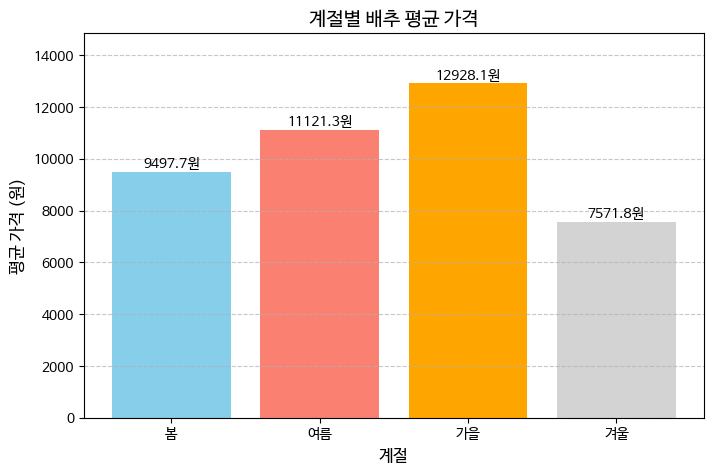

In [7]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = 'a54a77328b70a0e81d42c3bae44945d0ae0a9e8b26b4a065d394b8a3afd751be'

years = range(2015, 2025)
vrty_codes = ['01', '02', '03', '06'] # 봄배추, 여름배추, 가을배추, 월동배추
all_data = []

for year in years :
    for vc in vrty_codes :
        params = {
            'serviceKey': api_key,
            'pageNo': '1',
            'numOfRows': '200',
            'returnType': 'JSON',
            'cond[exmn_ymd::GTE]': f"{year}0101",
            'cond[exmn_ymd::LTE]': f"{year}1231",
            'cond[se_cd::EQ]': '02',
            'cond[ctgry_cd::EQ]': '200',
            'cond[item_cd::EQ]': '211',
            'cond[grd_cd::EQ]': '04',
            'cond[sgg_cd::EQ]': '1101',
            'cond[mrkt_cd::EQ]': '0110211',
            'cond[vrty_cd::EQ]': f'{vc}'
        }

        try:
            response = requests.get(url, params=params)
            # print( f"품번코드: {vc}, 년도: {year}년, 상태: {response.status_code}")
            if response.status_code == 200:
                result = response.json()
                items = result.get('response', {}).get('body', {}).get('items', {}).get('item', [])
                if items:
                    if isinstance(items, dict):
                        items = [items]
                    all_data.extend(items)
        except Exception as e:
            print(f"수집 중 오류: {e}")


# 2-1번
df = pd.DataFrame(all_data)
# print("------- DataFrame 기본 정보 -------")
# print(df.info())
# print("\n------- DataFrame 기본 정보 -------")
# print(df.head())

df['exmn_ymd'] = df['exmn_ymd'].astype(str)
df['year'] = df['exmn_ymd'].str[:4].astype(int)
df['month'] = df['exmn_ymd'].str[4:6].astype(int)


df['exmn_dd_prc'] = df['exmn_dd_prc'].astype(str).str.replace(',','').astype(float)

def get_season(month) :
    if( month in [3,4,5]) :
        return "봄"
    elif( month in [6,7,8]) :
        return "여름"
    elif( month in [9,10,11]) :
        return "가을"
    else :
        return "겨울"


df['season'] = df['month'].apply(get_season)
# print("\n------- 전처리 후 데이터 -------")
# print(df[['exmn_ymd', 'year', 'month', 'season', 'exmn_dd_prc']].head())


# student_id = "9087"
# year_avg = df.groupby("year")['exmn_dd_prc'].mean();

# plt.plot(year_avg.index, year_avg.values, marker='o',
#         linestyle='-', color = 'blue',label = '연도별 평균 가격')
# plt.title(f"연도별 배추 평균 가격변화 - {student_id}")
# plt.xlabel("연도", fontsize=12)
# plt.ylabel("평균 가격 (원)", fontsize=12)
# plt.grid(True)
# plt.legend()

# plt.savefig(f"yearly_cabbage_price_{student_id}.png")
# plt.show()


# 3-2
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False


season_order = ['봄', '여름', '가을', '겨울']
seasonal_avg = df.groupby('season')['exmn_dd_prc'].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(seasonal_avg.index, seasonal_avg.values, color=['skyblue', 'salmon', 'orange', 'lightgray'])

plt.title("계절별 배추 평균 가격", fontsize=14)
plt.xlabel("계절", fontsize=12)
plt.ylabel("평균 가격 (원)", fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f"{height:.1f}원",
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, seasonal_avg.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("seasonal_cabbage_price.png")
plt.show()

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/u